In [18]:
from architectures.poolformer import poolformer_s12
import torch

model = poolformer_s12(True)

params = torch.cat([p.flatten() for p in model.parameters() if p.requires_grad]).detach()

In [19]:
stats = {
    'mean': params.mean(),
    'std': params.std(),
    'min': params.min(),
    'max': params.max(),
    '0.5_percentile': params.quantile(0.005),
    '99.5_percentile': params.quantile(0.995),
}
print(stats)

{'mean': tensor(0.0010), 'std': tensor(0.1631), 'min': tensor(-17.2902), 'max': tensor(20.1362), '0.5_percentile': tensor(-0.2745), '99.5_percentile': tensor(0.2700)}


In [20]:
p_clamped = torch.clamp(params, stats['0.5_percentile'], stats['99.5_percentile'])
clamped_stats = {
    'mean': p_clamped.mean(),
    'std': p_clamped.std()
}
print(clamped_stats)

{'mean': tensor(0.0001), 'std': tensor(0.0940)}


<Axes: ylabel='Count'>

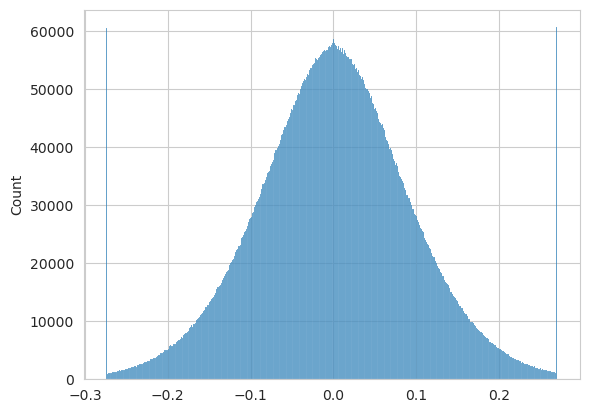

In [21]:
import seaborn as sns

sns.histplot(p_clamped)

# Test adding noise

In [22]:
for scale in [0.005, 0.01, 0.05, 0.1, 0.15]:
    print(clamped_stats['std'] * scale)

tensor(9.3992e-05)
tensor(0.0005)
tensor(0.0009)
tensor(0.0047)
tensor(0.0094)
tensor(0.0141)
tensor(0.0188)


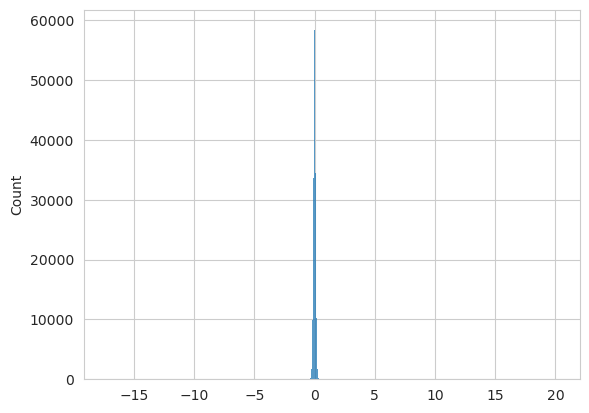

In [23]:
def plot_weight_distro(model):
    p = torch.cat([p.flatten() for p in model.parameters() if p.requires_grad]).detach()
    sns.histplot(p)

plot_weight_distro(model)
y_previous = model(torch.randn(1, 3, 224, 224)).detach()

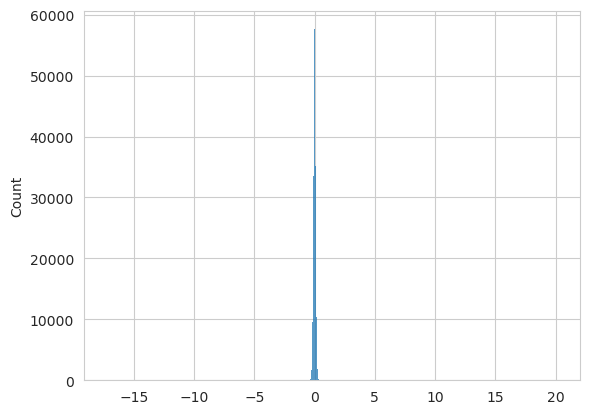

In [24]:
for p in model.parameters():
    if p.requires_grad:
        p.data = p.data + torch.randn_like(p) * 0.005

plot_weight_distro(model)
y_current = model(torch.randn(1, 3, 224, 224)).detach()

In [25]:
print(y_previous.norm())
print(y_current.norm())

tensor(11.2196)
tensor(11.6534)
